# AC-Video-JEPA data — the two-rooms `WallDataset`, at researcher altitude

This notebook explores the data behind `examples/ac_video_jepa`, surfacing **only the parts
that affect research decisions**. The ~700 lines of collision geometry in
`eb_jepa/datasets/two_rooms/wall_dataset.py` (`check_wall_intersection`, `segments_intersect`,
`check_pass_through_door`, expert-trajectory generation) are deliberately treated as a black box —
their complete summary is *"the dot can't pass through walls, except via the door"* — and we
**verify that physics empirically** instead of reading it.

What changed vs. Moving MNIST (video JEPA): the world no longer moves on its own. An **agent**
(a dot) moves through a **two-room arena** because of **actions**, and the ground-truth actions
ship with every sample — that's what makes this JEPA *action-conditioned*.

Steps:
1. `init_data` — the plumbing (two minutes, then move on)
2. The data contract — `WallSample`, the tensors the model actually sees
3. Frames — the two channels
4. The generative story — one trajectory with its actions drawn on top
5. Action semantics — the off-by-one, settled empirically
6. Collisions — actions record *intent*, not displacement
7. Cross-wall trajectories — `cross_wall_rate`
8. The config knobs that are experimental design, not plumbing

In [1]:
import random
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = Path.cwd().parents[1]          # examples/my_ac_video_jepa -> repo root
sys.path.insert(0, str(REPO_ROOT))

from eb_jepa.datasets.utils import init_data
from eb_jepa.datasets.two_rooms.utils import generate_wall_layouts

torch.manual_seed(0); np.random.seed(0); random.seed(0)

---
## 1. `init_data` — the plumbing

[eb_jepa/datasets/utils.py](../../eb_jepa/datasets/utils.py) is 67 lines with zero research
content: load `two_rooms/data_config.yaml`, merge our overrides, build a `WallDatasetConfig`,
wrap `WallDataset` in two standard `DataLoader`s. Read it once, move on.

The one thing worth internalizing: **there are no files on disk**. Every `__getitem__`
*simulates* a fresh 91-step episode (`n_steps: 91`) and cuts a random 17-step window out of it
(`sample_length: 17`). The dataset `size` is just how many samples one "epoch" pretends to have.

We shrink `size` so the notebook stays light (real training: `size=100000`, `batch_size=384`).

In [2]:
loader, val_loader, config = init_data(
    env_name="two_rooms",
    cfg_data={"size": 256, "batch_size": 64, "num_workers": 0, "device": "cpu"},
)
dset = loader.dataset

print("dataset class   :", type(dset).__name__)
print("img_size        :", config.img_size)          # 65   (from data_config.yaml)
print("n_steps         :", config.n_steps)           # 91   full simulated episode
print("sample_length   :", config.sample_length)     # 17   window the model sees
print("fix_wall        :", config.fix_wall)          # False -> wall/door randomized per sample
print("cross_wall_rate :", config.cross_wall_rate)   # 0.35
print("normalize       :", config.normalize)         # True
print("num layouts     :", len(dset.layouts))        # 2250 = 25 wall_x * 45 door_y * 2 types

dataset class   : WallDataset
img_size        : 65
n_steps         : 91
sample_length   : 17
fix_wall        : False
cross_wall_rate : 0.35
normalize       : True
num layouts     : 2250


---
## 2. The data contract — `WallSample`

This is the tier-1, must-know-cold part. Each batch is a `WallSample` NamedTuple with five
fields, and they play **two different roles**:

| Field | Shape | Role |
|---|---|---|
| `states` | `[B, 2, 17, 65, 65]` | **model input** — rendered frames, 2 channels (dot, walls) |
| `actions` | `[B, 2, 17]` | **model input** — ground-truth (dx, dy) displacement per step, *raw pixels* |
| `locations` | `[B, 2, 17]` | eval-only — true dot (x, y), **normalized** (used by the probe) |
| `wall_x` | `[B, 1]` | eval-only — wall x-coordinate, raw pixels |
| `door_y` | `[B, 1]` | eval-only — door y-coordinate, raw pixels |

`main.py` unpacks `x, a, loc, _, _` and feeds only `(x, a)` to the JEPA; `locations` exist so a
frozen probe can measure how much position information the representation keeps.

⚠️ The shape comments on `WallSample` in
[wall_dataset.py:18-23](../../eb_jepa/datasets/two_rooms/wall_dataset.py) say `[T, 1, 28, 28]` —
they are **stale**. Real states are 2-channel 65×65, laid out `[B, C, T, H, W]`
(channel first, then time), as the prints below show.

In [3]:
states, actions, locations, wall_x, door_y = next(iter(loader))

print("states    :", tuple(states.shape),    states.dtype)   # (64, 2, 17, 65, 65) [B, C, T, H, W]
print("actions   :", tuple(actions.shape),   actions.dtype)  # (64, 2, 17)         [B, xy, T]
print("locations :", tuple(locations.shape), locations.dtype)# (64, 2, 17)         [B, xy, T]
print("wall_x    :", tuple(wall_x.shape),    wall_x[:4].flatten().tolist())
print("door_y    :", tuple(door_y.shape),    door_y[:4].flatten().tolist())

states    : (64, 2, 17, 65, 65) torch.float32
actions   : (64, 2, 17) torch.float32
locations : (64, 2, 17) torch.float32
wall_x    : (64, 1) [41, 30, 26, 32]
door_y    : (64, 1) [14, 33, 31, 45]


---
## 3. Frames — two channels, z-scored

Channel 0 is the **dot** (a Gaussian blob, `dot_std=1.3`), channel 1 is the **walls** (border
frame + one inner wall with a door gap, `wall_width=3`, door height `2*door_space+1 = 9` px).
The wall channel is static within a trajectory — it exists so the model can *see* the layout,
since the layout changes across samples.

Pixel values are **not** `[0, 255]`: `normalize=True` min-max scales each frame, then z-scores
each channel with dataset-wide stats (`Normalizer.normalize_state`). Expect odd-looking ranges.

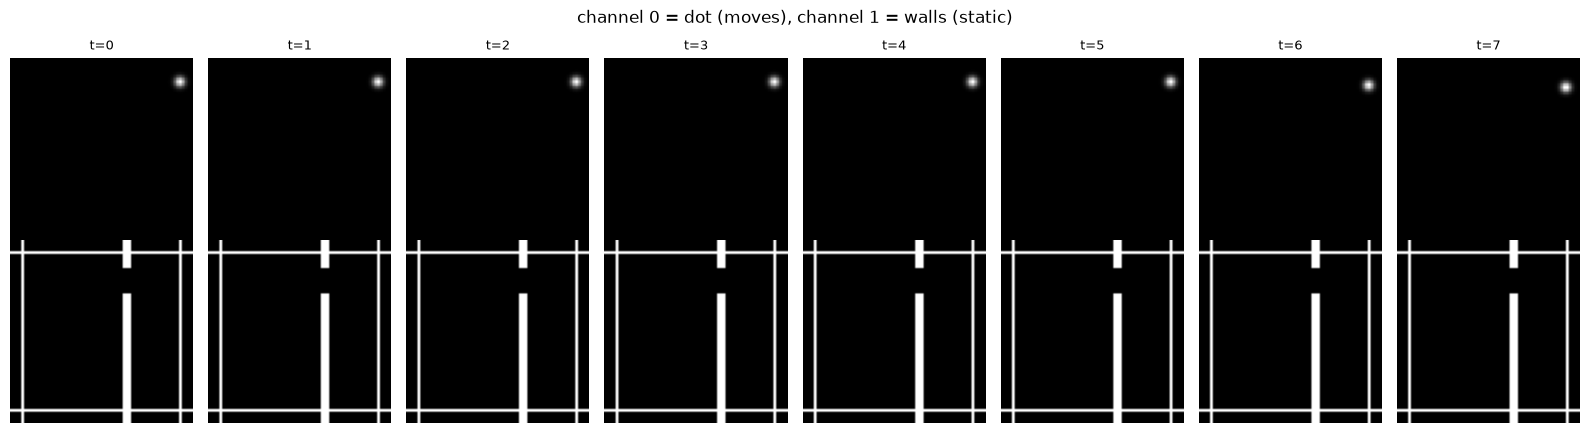

dot  channel range : -0.0704587996006012 .. 27.02907943725586
wall channel range : -0.3312112092971802 .. 3.0177392959594727


In [4]:
b = 0
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
for t in range(8):
    axes[0, t].imshow(states[b, 0, t], cmap="gray")
    axes[1, t].imshow(states[b, 1, t], cmap="gray")
    axes[0, t].set_title(f"t={t}", fontsize=9)
    axes[0, t].axis("off"); axes[1, t].axis("off")
fig.suptitle("channel 0 = dot (moves), channel 1 = walls (static)")
plt.tight_layout(); plt.show()

print("dot  channel range :", states[:, 0].min().item(), "..", states[:, 0].max().item())
print("wall channel range :", states[:, 1].min().item(), "..", states[:, 1].max().item())

---
## 4. The generative story — one trajectory, actions drawn on top

The tier-2 abstraction, with the numbers from `data_config.yaml`:

- start position: uniform over the arena (re-sampled if it lands inside the wall)
- direction: a **von Mises random walk** — each step's angle = previous angle + noise
  (`action_angle_noise: 0.2` rad), so trajectories are smooth, not jittery
- step length: truncated normal, mean `1.0` px, clipped to `[0.2, 1.8]` px
- 91 steps, walls/borders **block** movement, and with probability `0.35` the whole trajectory
  is replaced by one crafted to cross through the door (§7)

`locations` come back normalized (`Normalizer.normalize_location`), so we unnormalize before
plotting. `actions` are **already raw pixels** — that asymmetry is easy to forget.

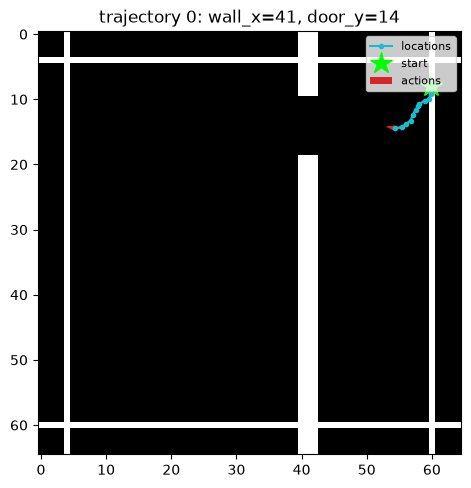

step lengths (px): min 0.33113113045692444  max 1.596919298171997


In [5]:
norm = dset.normalizer
loc_px = norm.unnormalize_location(locations.permute(0, 2, 1))   # [B, T, 2] in pixel coords
acts   = actions.permute(0, 2, 1)                                # [B, T, 2] already in pixels

b = 0
xs, ys = loc_px[b, :, 0].numpy(), loc_px[b, :, 1].numpy()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(states[b, 1, 0], cmap="gray")                 # wall channel as backdrop
ax.plot(xs, ys, "o-", ms=3, color="tab:cyan", label="locations")
ax.plot(xs[0], ys[0], "*", ms=16, color="lime", label="start")
ax.quiver(xs, ys, acts[b, :, 0].numpy(), acts[b, :, 1].numpy(),
          angles="xy", scale_units="xy", scale=1, color="tab:red",
          width=0.006, label="actions")
ax.set_title(f"trajectory {b}: wall_x={wall_x[b].item():.0f}, door_y={door_y[b].item():.0f}")
ax.legend(loc="upper right", fontsize=8)
plt.show()

print("step lengths (px): min", acts[b].norm(dim=-1).min().item(),
      " max", acts[b].norm(dim=-1).max().item())   # within [0.2, 1.8] by construction

---
## 5. Action semantics — which frame does `actions[:, :, t]` belong to?

The off-by-one every wire-up gets wrong once: is `actions[..., t]` the action *into* frame `t`
or *out of* it? The code answers it (the episode's last frame is dropped so frames align with
actions), but the reliable way to know is to check on data:

**claim: `loc[t] + action[t] = loc[t+1]`, i.e. `actions[..., t]` is taken FROM frame `t`.**

(Corollary: the last action `actions[..., 16]` points at a frame that isn't in the window.)

In [6]:
pred_next = loc_px[:, :-1] + acts[:, :-1]           # loc[t] + action[t]
err = (pred_next - loc_px[:, 1:]).norm(dim=-1)      # vs loc[t+1]   -> [B, 16]

consistent = err < 0.05                              # float noise ~1e-4; real steps are >= 0.2 px
print(f"steps where loc[t] + action[t] == loc[t+1]: {consistent.float().mean():.1%}")
print(f"residual on those steps: {err[consistent].max().item():.2e} px  (pure float error)")

bshow = consistent.float().mean(dim=1).argmax().item()   # a sample with clean, unblocked steps
print(f"\nmapping table, sample {bshow}:")
print(f"{'t':>2} {'loc[t]':>16} {'action[t]':>16} {'loc[t]+action[t]':>18} {'loc[t+1]':>16}")
for t in range(5):
    f = lambda v: f"({v[0]:6.2f},{v[1]:6.2f})"
    print(f"{t:>2} {f(loc_px[bshow, t]):>16} {f(acts[bshow, t]):>16} "
          f"{f(loc_px[bshow, t] + acts[bshow, t]):>18} {f(loc_px[bshow, t + 1]):>16}")

steps where loc[t] + action[t] == loc[t+1]: 70.6%
residual on those steps: 8.53e-06 px  (pure float error)

mapping table, sample 1:
 t           loc[t]        action[t]   loc[t]+action[t]         loc[t+1]
 0  ( 28.90, 20.72)  ( -0.80, -0.93)    ( 28.10, 19.79)  ( 28.10, 19.79)
 1  ( 28.10, 19.79)  ( -0.16, -0.22)    ( 27.94, 19.57)  ( 27.94, 19.57)
 2  ( 27.94, 19.57)  ( -0.55, -1.16)    ( 27.39, 18.42)  ( 27.39, 18.42)
 3  ( 27.39, 18.42)  ( -0.47, -0.38)    ( 26.92, 18.04)  ( 26.92, 18.04)
 4  ( 26.92, 18.04)  ( -0.43, -0.22)    ( 26.49, 17.82)  ( 26.49, 17.82)


---
## 6. Where consistency breaks: collisions — actions record *intent*

The steps that fail the check above are not bugs — they are **collisions**. When the intended
move would cross a wall or border, the environment keeps the dot in place
([wall_dataset.py:995-1005](../../eb_jepa/datasets/two_rooms/wall_dataset.py)) but the stored
action is **unchanged**. So the action channel says "move 1 px left" while the pixels show
nothing moved.

This is a deliberate research-relevant property: the action alone does not determine the next
state — **the model has to learn wall geometry from pixels** to predict correctly. If actions
were the realized displacements, a world model could ignore the image entirely.

Blocked steps are also *common* (~30% of steps in a typical batch), not rare: the direction is
a smooth random walk, so a dot that hits a border keeps pushing into it for several steps
before its angle drifts away.

In [7]:
blocked = ~consistent                               # [B, 16]
print(f"blocked steps in this batch: {blocked.float().mean():.1%}")

bi, ti = blocked.nonzero()[0]
realized = (loc_px[bi, ti + 1] - loc_px[bi, ti]).norm()
print(f"example: sample {bi.item()}, step {ti.item()}:")
print(f"  intended |action|      = {acts[bi, ti].norm().item():.2f} px")
print(f"  realized displacement  = {realized.item():.2e} px   (dot stayed put)")

blocked steps in this batch: 29.4%
example: sample 0, step 0:
  intended |action|      = 0.66 px
  realized displacement  = 0.00e+00 px   (dot stayed put)


---
## 7. Cross-wall trajectories — `cross_wall_rate = 0.35`

A free-roaming dot rarely finds the 9-px door, so 35% of *episodes* are replaced by
trajectories crafted to pass through it (`generate_cross_wall_state_and_actions` — tier 3,
skipped). Without this, door transitions would be near-absent from training data and no world
model could learn them.

The fraction of *samples* that actually contain a crossing is lower than 0.35: the 17-step
window is cut at a random offset of the 91-step episode and can miss the crossing moment.

samples whose window contains a crossing: 9.4%  (< 0.35, see above)


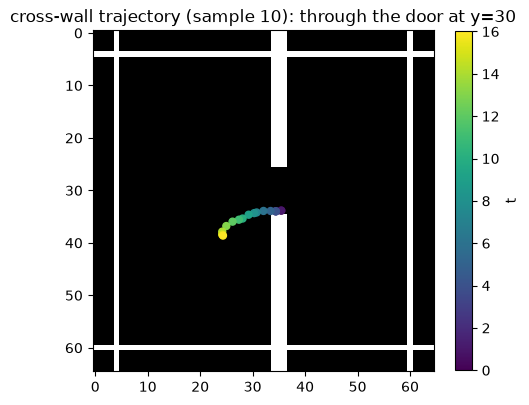

In [8]:
def find_crossings(loc_px, wall_x):
    side = torch.sign(loc_px[..., 0] - wall_x.float())    # [B, T]: -1 left of wall, +1 right
    return (side.max(dim=1).values > 0) & (side.min(dim=1).values < 0)

crossed = find_crossings(loc_px, wall_x)
print(f"samples whose window contains a crossing: {crossed.float().mean():.1%}  (< 0.35, see above)")

# grab one crossing trajectory (redraw batches if this one has none)
tries = 0
while not crossed.any() and tries < 20:
    states, actions, locations, wall_x, door_y = next(iter(loader))
    loc_px = norm.unnormalize_location(locations.permute(0, 2, 1))
    crossed = find_crossings(loc_px, wall_x)
    tries += 1

b = crossed.nonzero()[0].item()
xs, ys = loc_px[b, :, 0].numpy(), loc_px[b, :, 1].numpy()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(states[b, 1, 0], cmap="gray")
sc = ax.scatter(xs, ys, c=range(len(xs)), cmap="viridis", s=25, zorder=3)
ax.plot(xs, ys, "-", color="w", lw=0.7, alpha=0.6)
fig.colorbar(sc, ax=ax, label="t", shrink=0.8)
ax.set_title(f"cross-wall trajectory (sample {b}): through the door at y={door_y[b].item():.0f}")
plt.show()

---
## 8. Config knobs that are experimental design, not plumbing

Most of `data_config.yaml` is cosmetics. These knobs change **what your experiment measures**:

| Knob | Default | What it decides |
|---|---|---|
| `fix_wall` (+ `fix_wall_location`, `fix_door_location`) | `false` | one fixed layout vs. a *distribution* of layouts — i.e. whether the model must infer geometry from pixels at all |
| `exclude_wall_train` / `exclude_door_train` / `only_wall_val` / `only_door_val` | all empty | **held-out-layout generalization split** — train never sees some wall positions, eval uses only those |
| `cross_wall_rate` | `0.35` | how often door transitions appear in training data — door-passing skill lives or dies here |
| `sample_length` vs `n_steps` | `17` / `91` | context the model trains on vs. episode length (long-rollout eval bumps `sample_length` to 90) |
| `normalize` | `true` | locations and pixels are z-scored; **actions are not** — remember when decoding/planning |

Note the defaults: all split strings empty ⇒ **training sees every layout**. The held-out-wall
generalization experiment is opt-in. Below, the split machinery in action:

In [9]:
split_cfg = replace(config, fix_wall=False,
                    exclude_wall_train="30-34", exclude_door_train="10-54",   # exclude walls 30..34
                    only_wall_val="30-34",      only_door_val="10-54")        # (10-54 = all doors)

train_layouts, _ = generate_wall_layouts(split_cfg)
val_layouts, _   = generate_wall_layouts(replace(split_cfg, train=False))

train_walls = sorted({v["wall_pos"] for v in train_layouts.values()})
val_walls   = sorted({v["wall_pos"] for v in val_layouts.values()})
print("train layouts:", len(train_layouts), "  wall_x values:", train_walls)
print("val   layouts:", len(val_layouts),   "  wall_x values:", val_walls)
print("overlap      :", set(train_walls) & set(val_walls))    # empty = clean split

train layouts: 1800   wall_x values: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
val   layouts: 450   wall_x values: [30, 31, 32, 33, 34]
overlap      : set()


Two quirks worth knowing (harmless, but confusing if you hit them cold):

- exclusion is the **Cartesian AND**: a layout is dropped from training only if its wall is in
  `exclude_wall_train` *and* its door is in `exclude_door_train` — so to hold out wall positions
  entirely, set the door range to everything (as above).
- layouts come in `"v"` and `"h"` types, but the type is **never used** downstream
  ([wall_dataset.py:1079-1085](../../eb_jepa/datasets/two_rooms/wall_dataset.py) collects it and
  drops it) — every wall renders vertical, so the layout count is effectively double-counted.

---
## Recap

| Know cold (tier 1) | Know as a story (tier 2) | Safely abstracted (tier 3) |
|---|---|---|
| `states [B,2,17,65,65]`, `actions [B,2,17]` are model input | von Mises random walk, steps 0.2–1.8 px, 91-step episodes, 17-step windows | `check_wall_intersection`, `segments_intersect`, `check_pass_through_door` |
| `locations`/`wall_x`/`door_y` are eval-only | collisions block movement; `cross_wall_rate=0.35` injects door crossings | `generate_expert_cross_wall_state_and_actions` |
| `actions[t]` is taken FROM frame `t` | layouts randomized per sample; split knobs enable held-out-wall generalization | `render_location` / `render_walls` internals |
| actions = **intent**, not displacement; raw px while locations are normalized | | |

Verified empirically here — with no geometry code read: the action↔frame alignment (§5), that
blocked actions leave the dot in place (§6), and that crossings exist at roughly the configured
rate (§7). Next stop: `cc_main.ipynb`, where `(states, actions)` feed the `RNNPredictor`.